In [356]:
import pandas as pd
import numpy as np
import plotly.graph_objects as go
from plotly.subplots import make_subplots

База: загрузка датасета

In [357]:
data = pd.read_csv('data_ab.csv')

In [358]:
data.head()

,user_id,timestamp,group,landing_page,converted
0,851104,2025-01-21 22:11:48.556739,control,old_page,0
1,804228,2025-01-12 08:01:45.159739,control,old_page,0
2,661590,2025-01-11 16:55:06.154213,treatment,new_page,0
3,853541,2025-01-08 18:28:03.143765,treatment,new_page,0
4,864975,2025-01-21 01:52:26.210827,control,old_page,1


* `user_id` — уникальный идентификатор пользователя;

* `timestamp` — время посещения пользователем страницы;

* `group` — группа эксперимента, к которой был случайно отнесён пользователь:

  *   `control` — контрольная группа,
  *   `treatment` — экспериментальная группа;

* `landing_page` — версия лендинга, которую увидел пользователь:

  *   `old_page` — старая версия страницы,
  *   `new_page` — новая версия страницы;

* `converted` — бинарный признак, показывающий, совершил ли пользователь целевое действие (целевым действием является регистрация на курс).

Наша целевая переменная это совершение целевого действия пользователем.

In [359]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 294478 entries, 0 to 294477
Data columns (total 5 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   user_id       294478 non-null  int64 
 1   timestamp     294478 non-null  object
 2   group         294478 non-null  object
 3   landing_page  294478 non-null  object
 4   converted     294478 non-null  int64 
dtypes: int64(2), object(3)
memory usage: 11.2+ MB


In [360]:
data.isna().sum()

user_id         0
timestamp       0
group           0
landing_page    0
converted       0
dtype: int64

пропусков нет

In [361]:
mask = (data['group'] == 'treatment') & (data['landing_page'] == 'old_page') | (data['group'] == 'control') & (data['landing_page'] == 'new_page')

In [362]:
data[mask]

,user_id,timestamp,group,landing_page,converted
22,767017,2025-01-12 22:58:14.991443,control,new_page,0
240,733976,2025-01-11 15:11:16.407599,control,new_page,0
308,857184,2025-01-20 07:34:59.832626,treatment,old_page,0
327,686623,2025-01-09 14:26:40.734775,treatment,old_page,0
357,856078,2025-01-12 12:29:30.354835,treatment,old_page,0
...,...,...,...,...,...
294014,813406,2025-01-09 06:25:33.223301,treatment,old_page,0
294200,928506,2025-01-13 21:32:10.491309,control,new_page,0
294252,892498,2025-01-22 01:11:10.463211,treatment,old_page,0
294253,886135,2025-01-06 12:49:20.509403,control,new_page,0


3893 значений, которые противоречат нашему тесту(По замыслу A/B-теста контрольной группе (`control`) должна была показываться старая версия лендинга — `old_page`; экспериментальной группе (`treatment`) должна была показываться новая версия лендинга — `new_page`). Эти данные нужно удалить, так как они будут создавать шум и искажать значения

In [363]:
data = data[-mask]

In [364]:
data['timestamp'] = pd.to_datetime(data['timestamp'])
data['date'] = data['timestamp'].dt.date
data['weekday'] = data['timestamp'].dt.weekday
data['hour'] = data['timestamp'].dt.hour

In [365]:
data.head()

,user_id,timestamp,group,landing_page,converted,date,weekday,hour
0,851104,2025-01-21 22:11:48.556739,control,old_page,0,2025-01-21,1,22
1,804228,2025-01-12 08:01:45.159739,control,old_page,0,2025-01-12,6,8
2,661590,2025-01-11 16:55:06.154213,treatment,new_page,0,2025-01-11,5,16
3,853541,2025-01-08 18:28:03.143765,treatment,new_page,0,2025-01-08,2,18
4,864975,2025-01-21 01:52:26.210827,control,old_page,1,2025-01-21,1,1


Проверим группы на независимость(кол-во пользователей, которые есть в обеих гурппах)

In [366]:
control = data[data['group'] == 'control']['user_id']
treatment = data[data['group'] == 'treatment']['user_id']

both = []

for c in control:
    if c in treatment.values:
        both.append(c)

In [367]:
both

[]

Наши группы независимы

Посмотрим разделение по классам

In [368]:
print(data['group'].value_counts()) #без принта почему-то криво выводит

group
treatment    145311
control      145274
Name: count, dtype: int64


In [369]:
print(data['converted'].value_counts())

converted
0    255832
1     34753
Name: count, dtype: int64


Целевое действие совершает меньше чем 20% пользователей.

In [370]:
size = len(data)

In [371]:
print(data['group'].value_counts()/size)

group
treatment    0.500064
control      0.499936
Name: count, dtype: float64


распределение групп почти 50/50

In [372]:
print(data['converted'].value_counts()/size)

converted
0    0.880403
1    0.119597
Name: count, dtype: float64


88% пользователей не совершают целевое действие независимо от группы

In [373]:
group_a = data[data['group'] == 'control']
group_b = data[data['group'] == 'treatment']

size_a = len(group_a)
size_b = len(group_b)

In [374]:
print(group_a['converted'].value_counts()/size_a)
print(group_b['converted'].value_counts()/size_b)

print(group_a['converted'].mean())
print(group_b['converted'].mean())

converted
0    0.879614
1    0.120386
Name: count, dtype: float64
converted
0    0.881193
1    0.118807
Name: count, dtype: float64
0.1203863045004612
0.11880724790277405


Исходя из полученных данных мы можем предположить, что новая версия страницы сделала только хуже. Она уменьшает конверсию на 1%.

Но делать такие поспешные выводы мы не можем, так как у нас нет статистически значимых оснований так говорить.

Посмотрим на колонку с временем.

In [375]:
group_by_date = data.groupby(['date', 'group'])['user_id'].count()

In [376]:
group_by_date/size

date        group    
2025-01-02  control      0.009839
            treatment    0.009818
2025-01-03  control      0.022678
            treatment    0.022775
2025-01-04  control      0.022637
            treatment    0.022510
2025-01-05  control      0.022117
            treatment    0.022386
2025-01-06  control      0.022733
            treatment    0.023219
2025-01-07  control      0.022727
            treatment    0.022744
2025-01-08  control      0.023012
            treatment    0.023057
2025-01-09  control      0.022809
            treatment    0.022764
2025-01-10  control      0.022899
            treatment    0.023043
2025-01-11  control      0.023016
            treatment    0.022964
2025-01-12  control      0.022444
            treatment    0.022840
2025-01-13  control      0.022548
            treatment    0.022396
2025-01-14  control      0.022534
            treatment    0.022713
2025-01-15  control      0.023105
            treatment    0.022537
2025-01-16  control      0

Группы однородны также по дням

In [377]:
group_by_date = data.groupby('date')['converted'].mean()

In [378]:
group_by_date.reset_index()

,date,converted
0,2025-01-02,0.122724
1,2025-01-03,0.113795
2,2025-01-04,0.119293
3,2025-01-05,0.119084
4,2025-01-06,0.119449
5,2025-01-07,0.118595
6,2025-01-08,0.119818
7,2025-01-09,0.118855
8,2025-01-10,0.119625
9,2025-01-11,0.116982


In [379]:
group_by_date = group_by_date.reset_index()

Мы получили общую конверсию по датам независимо от группы

In [380]:
conversion = go.Scatter(x=group_by_date['date'], y=group_by_date['converted'])

fig = go.Figure(conversion, layout_title_text="График конверсии по датам, независимо от группы")

fig.show()

In [381]:
group_A_by_date = group_a.groupby('date')['converted'].mean()

In [382]:
group_A_by_date = group_A_by_date.reset_index()

In [383]:
group_B_by_date = group_b.groupby('date')['converted'].mean()

In [384]:
group_B_by_date = group_B_by_date.reset_index()

Распрделение пользователей по датам равноемерное

In [385]:
figA = go.Scatter(x=group_A_by_date['date'], y=group_A_by_date['converted'], name='Группа A')
figB = go.Scatter(x=group_B_by_date['date'], y=group_B_by_date['converted'], name='Группа B')

data_new = [figA, figB]

fig = go.Figure(data_new, layout_title_text="Графики конверсии по датам для групп A и B")

fig.show()

In [386]:
group_by_weekday = data.groupby('weekday')['converted'].mean()

In [387]:
days = {0: 'Понедельник', 1: 'Вторник', 2: 'Среда', 3: 'Четверг', 4: 'Пятница', 5: 'Суббота', 6: 'Воскресенье'}

In [388]:
group_by_weekday = group_by_weekday.reset_index()

In [389]:
group_by_weekday['weekday'] = group_by_weekday['weekday'].replace(days)

In [390]:
conversion = go.Scatter(x=group_by_weekday['weekday'], y=group_by_weekday['converted'])

fig = go.Figure(conversion, layout_title_text="График конверсии по дням недели, независимо от группы")

fig.show()

In [401]:
group_A_by_weekday = group_a.groupby('weekday')['converted'].mean()

In [402]:
group_A_by_weekday = group_A_by_weekday.reset_index() 

In [403]:
group_A_by_weekday['weekday'] = group_A_by_weekday['weekday'].replace(days)

In [404]:
group_B_by_weekday = group_b.groupby('weekday')['converted'].mean()

In [405]:
group_B_by_weekday = group_B_by_weekday.reset_index()

Распределние пользователей по дням недели тоже равноемерно

In [406]:
group_B_by_weekday['weekday'] = group_B_by_weekday['weekday'].replace(days)

In [407]:
figA = go.Scatter(x=group_A_by_weekday['weekday'], y=group_A_by_weekday['converted'], name='Группа A')
figB = go.Scatter(x=group_B_by_weekday['weekday'], y=group_B_by_weekday['converted'], name='Группа B')

data_new = [figA, figB]

fig = go.Figure(data_new, layout_title_text="Графики конверсии по дням недели для групп A и B")

fig.show()

In [408]:
group_by_hour = data.groupby('hour')['converted'].mean()

In [409]:
group_by_hour = group_by_hour.reset_index()

In [410]:
conversion = go.Scatter(x=group_by_hour['hour'], y=group_by_hour['converted'])

fig = go.Figure(conversion, layout_title_text="График конверсии по часам, независимо от группы")

fig.show()

In [418]:
group_A_by_hour = group_a.groupby('hour')['converted'].mean()

In [419]:
group_A_by_hour = group_A_by_hour.reset_index()

In [420]:
group_B_by_hour = group_b.groupby('hour')['converted'].mean()

In [421]:
group_B_by_hour = group_B_by_hour.reset_index()

In [422]:
figA = go.Scatter(x=group_A_by_hour['hour'], y=group_A_by_hour['converted'], name='Группа A')
figB = go.Scatter(x=group_B_by_hour['hour'], y=group_B_by_hour['converted'], name='Группа B')

data_new = [figA, figB]

fig = go.Figure(data_new, layout_title_text="Графики конверсии по часам для групп A и B")

fig.show()

## Проверка зависимости результатов от дня недели или даты

Для того чтобы узнать есть-ли какая-то статистически значимая связь между конверсией и временем нужно провести статистические тесты

### Тест 1(распредление по дням недели)

- H0: распределение пользователей по дням недели **одинаково** для двух групп
- H1: распределение пользователей по дням недели **отличается** для двух групп

In [ ]:
from scipy.stats import chi2_contingency

In [ ]:
data.groupby('weekday')['converted'].value_counts().unstack()

converted,0,1
weekday,,
0,35002,4624
1,34877,4793
2,35186,4729
3,39935,5505
4,41512,5636
5,34804,4761
6,34516,4705


In [ ]:
table = data.groupby('weekday')['converted'].value_counts().unstack()

In [ ]:
stat, pvalue, dof, expected = chi2_contingency(table)

In [ ]:
stat, pvalue

(np.float64(5.512909523228607), np.float64(0.47989778851194875))

pvalue получилось больше чем наш уровень значимости(0.05), значит мы не отвергаем нашу нулевую гипотезу о независимости конверсии от дня недели.  

### Тест 2(распределение по датам)

- H0: распределение пользователей по датам **одинаково** для двух групп
- H1: распределение пользователей по датам **отличается** для двух групп

In [ ]:
data.groupby('date')['converted'].value_counts().unstack()

converted,0,1
date,,
2025-01-02,5011,701
2025-01-03,11705,1503
2025-01-04,11554,1565
2025-01-05,11392,1540
2025-01-06,11758,1595
2025-01-07,11646,1567
2025-01-08,11783,1604
2025-01-09,11669,1574
2025-01-10,11753,1597


In [ ]:
table = data.groupby('date')['converted'].value_counts().unstack()

In [ ]:
stat, pvalue, dof, expected = chi2_contingency(table)

In [ ]:
stat, pvalue

(np.float64(23.439156344751332), np.float64(0.37729788505528356))

pvalue получилось больше чем наш уровень значимости(0.05), значит мы не отвергаем нашу нулевую гипотезу о независимости конверсии от даты. 

### Тест 3(распределение по часам)

- H0: распределение пользователей по часам **одинаково** для двух групп
- H1: распределение пользователей по часам **отличается** для двух групп

In [423]:
data.groupby('hour')['converted'].value_counts().unstack()

converted,0,1
hour,,
0,10475,1433
1,10857,1393
2,10702,1368
3,10727,1394
4,10642,1371
5,10762,1480
6,10595,1463
7,10731,1430
8,10694,1437


In [424]:
table = data.groupby('hour')['converted'].value_counts().unstack()

In [425]:
stat, pvalue, dof, expected = chi2_contingency(table)

In [426]:
stat, pvalue

(np.float64(34.226265204017324), np.float64(0.06195652158634765))

pvalue получилось больше чем наш уровень значимости(0.05), значит мы не отвергаем нашу нулевую гипотезу о независимости конверсии от времени суток. 

Так как мы убедились что группы распределны по дням и датам равномерны, мы можем выдвинуть нашу нулевую гипотезу.

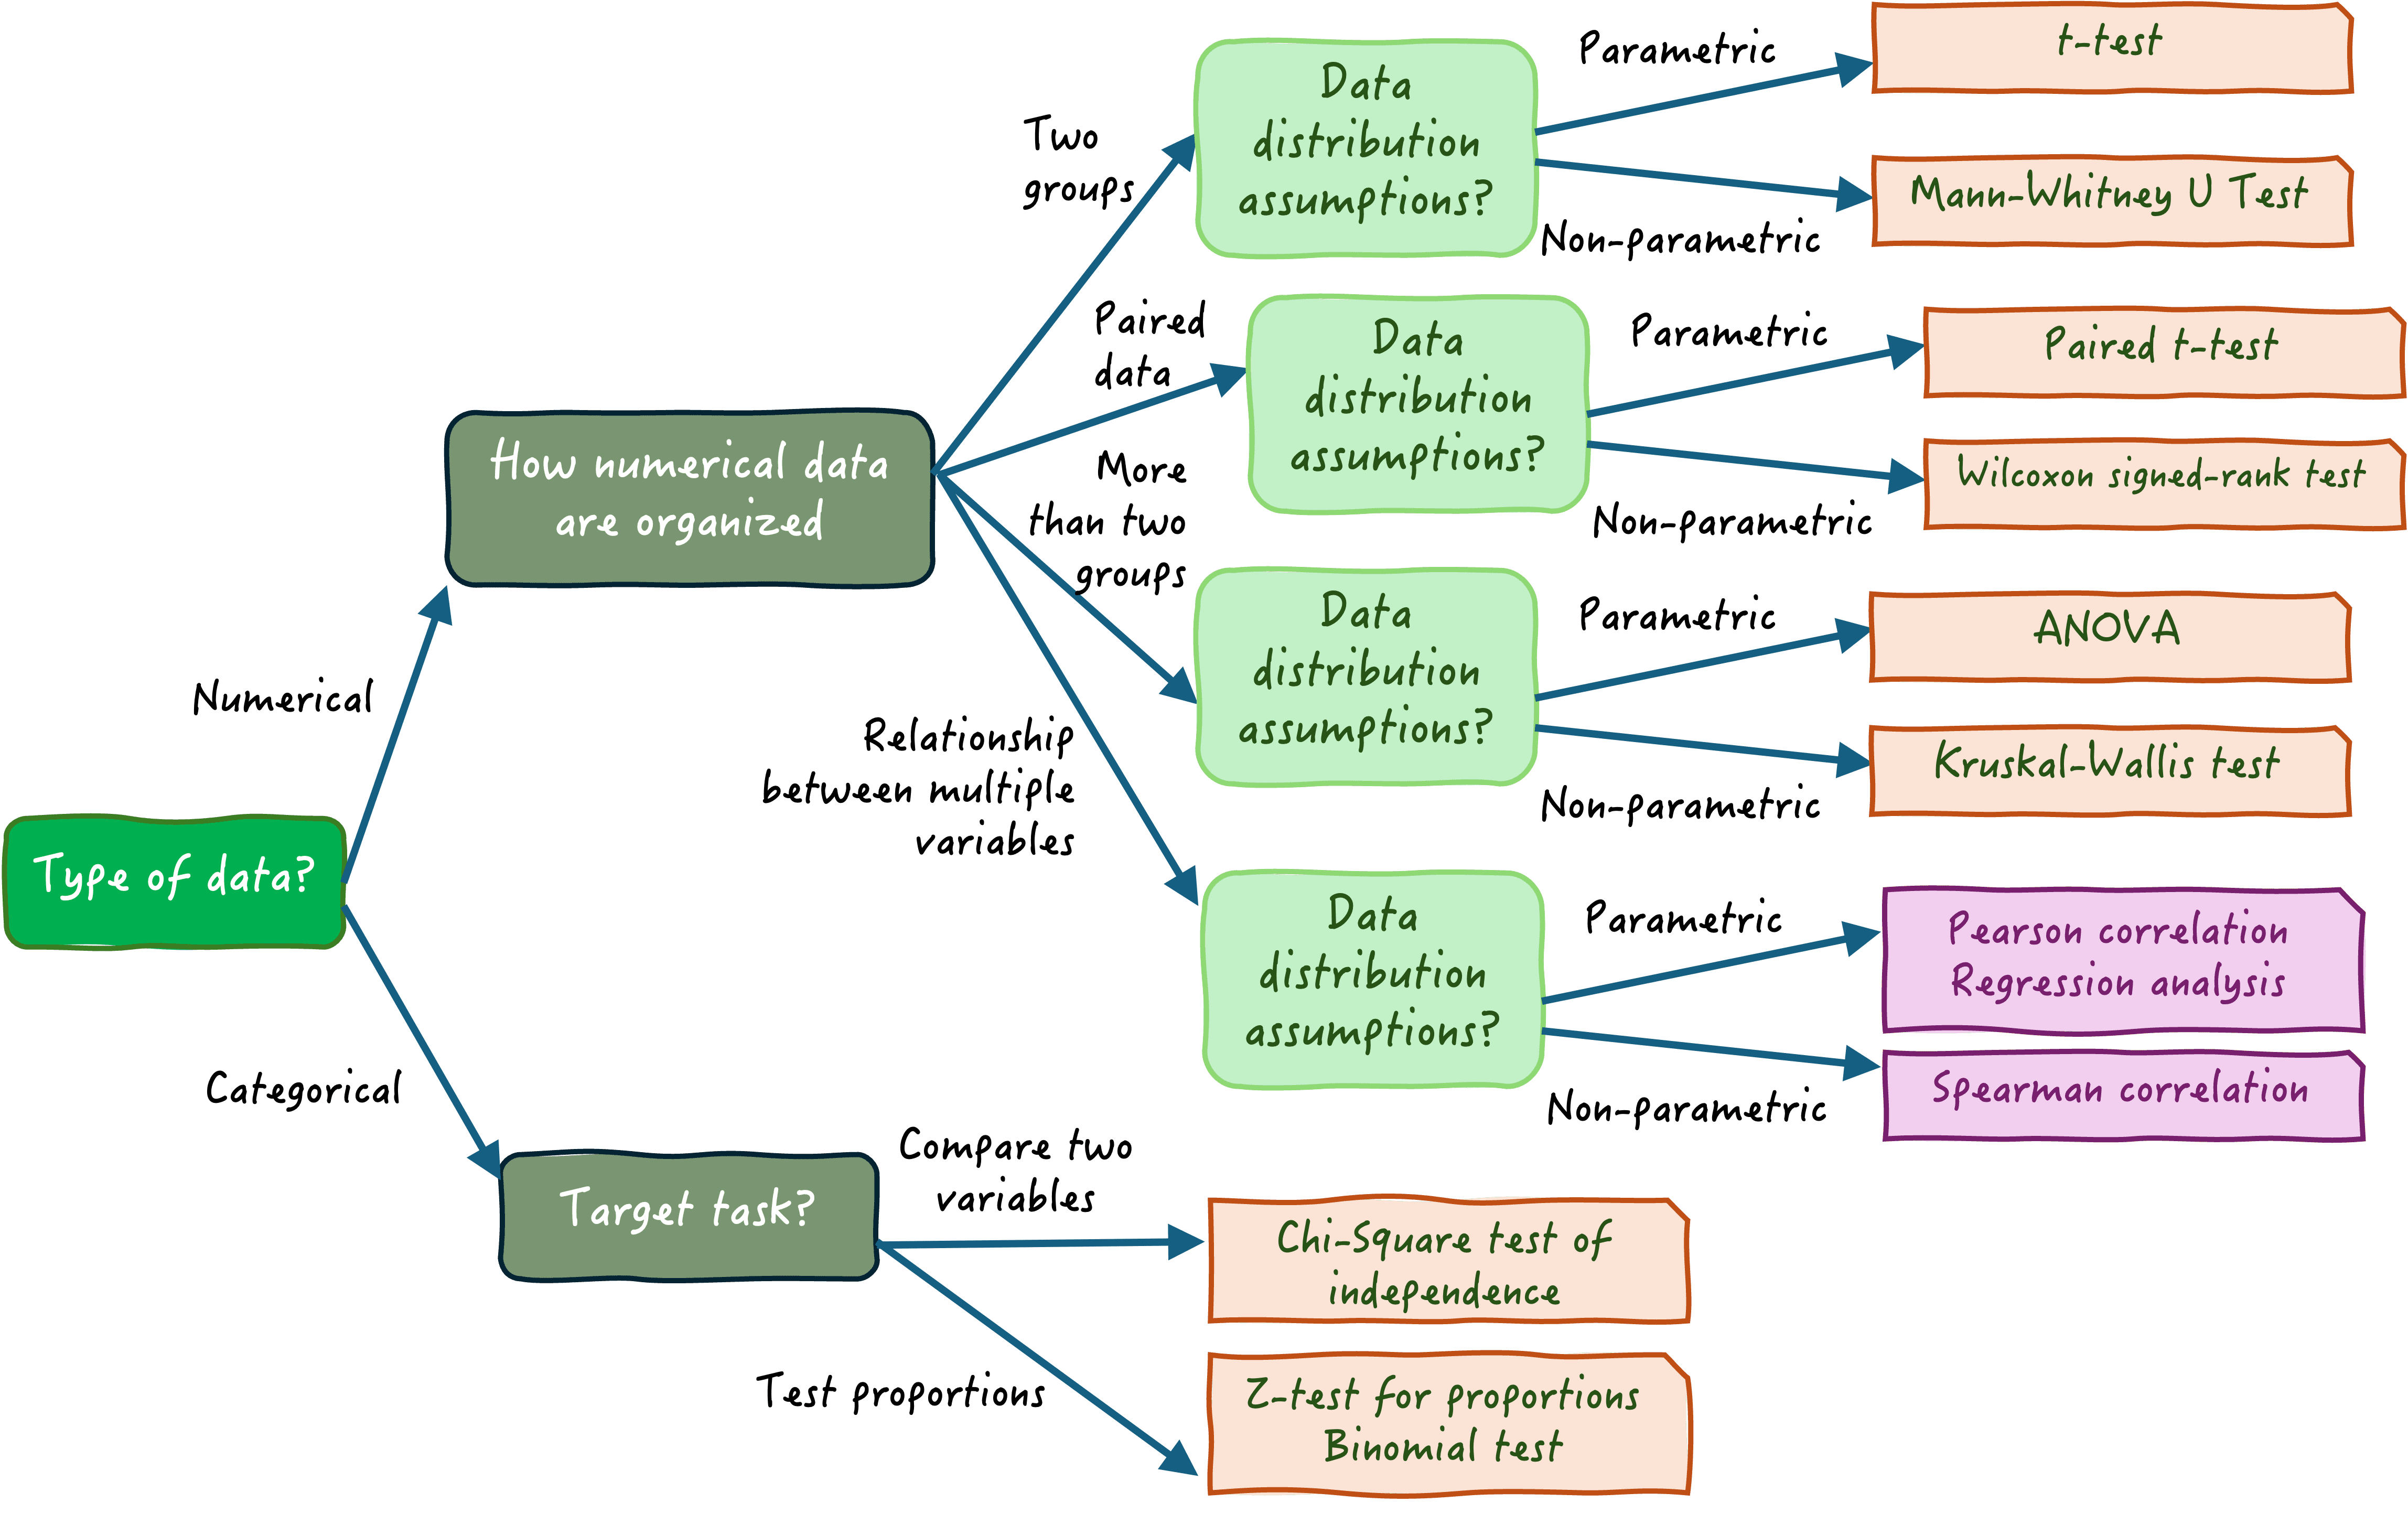

Наша нулевая гипотеза: конверия на новой странице не отличается от конверсии на старой странице

Таким обраом наша альтернативная гипотеза: конверсия на новой странице отличается от конверсии на старой странице

Так как наша целевая переменная бинарная и мы сравниваем долю конверсий по двум группам. Наши группы независимые, то мы выбираем Z-test for proportions

[proportions_ztest](https://www.statsmodels.org/stable/generated/statsmodels.stats.proportion.proportions_ztest.html)

In [ ]:
from scipy.stats import zscore
from scipy.stats import mannwhitneyu
from statsmodels.stats.proportion import proportions_ztest

In [ ]:
control = data[data['group'] == 'control']['converted']
treatment = data[data['group'] == 'treatment']['converted']

In [ ]:
stat, p_value = mannwhitneyu(control, treatment)

In [ ]:
stat, p_value

(np.float64(10571621978.5), np.float64(0.18965336487086848))

In [ ]:
positive = [control.sum(), treatment.sum()]

In [ ]:
size = [len(control), len(treatment)]

In [ ]:
stat, p_value = proportions_ztest(positive, size)

In [ ]:
stat, p_value

(np.float64(1.3116075339133115), np.float64(0.18965258971881804))

Статичтисечески значимых различий между control и treatment нет, значит нулевую гипотезу об отсутсвии отличия в конверсии между двумя версиями страницами не отвергаем.